In [ ]:
# MGV
import polars as pl

mgv = pl.read_csv('https://portal.nersc.gov/cfs/m342/MGV/MGV_v1.0_2021_07_08/mgv_contig_info.tsv', separator='\t', ignore_errors=True)

mgv_plot_df = (
    mgv
        .filter(pl.col('checkv_quality').is_not_null())
        .with_columns([
            pl.col('checkv_quality').str.replace('Complete', 'High-quality'),
            pl.lit('MGV').alias('database')
        ])
        .group_by('checkv_quality')
        .agg([
            pl.col('database').len().alias('count'),
            pl.col('database').first().alias('database')
        ])
)

In [ ]:
# GPD
import polars as pl

gpd = pl.read_csv('https://ftp.ebi.ac.uk/pub/databases/metagenomics/genome_sets/gut_phage_database/GPD_metadata.tsv', separator='\t', ignore_errors=True)
gpd_plot_df = (
    gpd
        .with_columns([
            pl.col('checkV_completion').str.replace("NA", 0).cast(pl.Float64),
        ])
        .with_columns([
            pl.when(pl.col('checkV_completion') == 0)
                .then(pl.lit('Not-determined'))
                .when(pl.col('checkV_completion') >= 90)
                .then(pl.lit('High-quality'))
                .when(pl.col('checkV_completion') > 50)
                .then(pl.lit('Medium-quality'))
                .otherwise(pl.lit('Low-quality'))
                .alias('checkv_quality'),
                pl.lit('GPD').alias('database')
        ])
        .group_by('checkv_quality')
        .agg([
            pl.col('database').len().alias('count'),
            pl.col('database').first().alias('database')
        ])
)

In [ ]:
# MMGE
!wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
!unzip all_mge_inf.zip -d mmge_data

import polars as pl

mmge = pl.read_csv('mmge_data/all_mge_inf.csv', ignore_errors=True)

mmge_plot_df = (
    mmge
        .filter(pl.col('status').str.contains('phage'))
        .filter(pl.col('checkv_genome_quality') != 'nan')
        .filter(pl.col('checkv_genome_quality').is_not_null())
        .rename({'checkv_genome_quality': 'checkv_quality'})
        .with_columns([
            pl.col('checkv_quality').str.replace('Complete', 'High-quality'),
            pl.lit('MMGE').alias('database')
        ])
        .group_by('checkv_quality')
        .agg([
            pl.col('database').len().alias('count'),
            pl.col('database').first().alias('database')
        ])
)

In [ ]:
# UHGV

import polars as pl

uhgv_meta = pl.read_csv('https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv', separator='\t', ignore_errors=True)

uhgv_plot_df = (
    uhgv_meta
        .with_columns([
            pl.col('checkv_quality').str.replace('Complete', 'High-quality'),
            pl.lit('UHGV').alias('database')
        ])
        .group_by('checkv_quality')
        .agg([
            pl.col('database').len().alias('count'),
            pl.col('database').first().alias('database')
        ])
)

In [ ]:
# IMG/VR
# metadata downloaded from:
# https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR#

import polars as pl

imgvr_meta = pl.read_csv('IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology', 'Confidence', 'Estimated completeness'])

imgvr_meta_cat = (
    imgvr_meta
        .with_columns([
            pl.col('Estimated completeness').replace('NA', None).cast(pl.Float64),
        ])
        .with_columns([
            pl.when(pl.col('Estimated completeness') >= 90)
            .then(pl.lit("High-quality"))
            .when(pl.col('Estimated completeness') >= 50)
            .then(pl.lit("Medium-quality"))
            .when(pl.col('Estimated completeness') >= 0)
            .then(pl.lit("Low-quality"))
            .otherwise(pl.lit("Not-determined"))
            .alias('checkv_quality')
        ])
)

imgvr_plot_df = (
    imgvr_meta_cat
        .with_columns([
            pl.lit('IMGVR').alias('database')
        ])
        .group_by('checkv_quality')
        .agg([
            pl.col('database').len().alias('count'),
            pl.col('database').first().alias('database')
        ])
)

Text(0.5, 1.0, 'Metagenomic virus database completeness values')

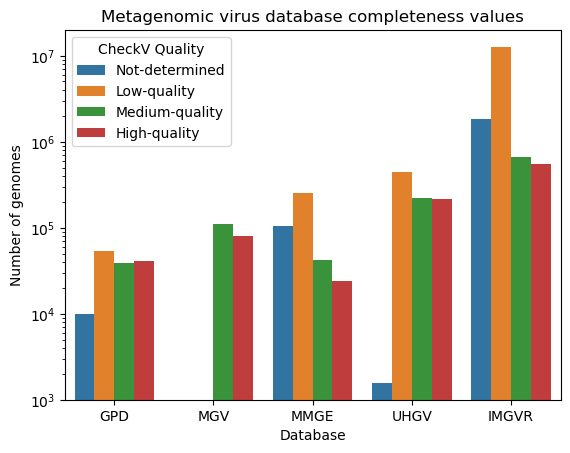

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = (
    pl.concat([gpd_plot_df, mgv_plot_df, mmge_plot_df, uhgv_plot_df, imgvr_plot_df])
        .rename({'checkv_quality': 'CheckV Quality'})
)

sns.barplot(data=plot_df, x='database', y='count', hue='CheckV Quality', hue_order=['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality'])
plt.yscale('log')
plt.ylabel('Number of genomes')
plt.xlabel('Database')
plt.title('Metagenomic virus database completeness values')

In [70]:
plot_df.filter(pl.col('database') == 'IMGVR').group_by('CheckV Quality').agg(pl.col('count').sum())

CheckV Quality,count
str,u32
"""Medium-quality""",671059
"""High-quality""",546779
"""Low-quality""",12608494
"""Not-determined""",1851291
